In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import gc

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

import torch
import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

"""FINAL WARNING: UserWarning silenced!"""
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()          # release cached blocks to the driver
    torch.cuda.ipc_collect()          # clean up inter-process caches
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.reset_accumulated_memory_stats()
    torch.cuda.synchronize()          # optional: ensure all work done

# Load genes

In [3]:
%%time
fpath="/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference/refdata-gex-GRCh38-2024-A_genes.csv.gz"
gdf = pd.read_csv(fpath, low_memory=False)
print(f"{gdf.shape=}")

# gdf.head()

# map from ensmbl IDs to gene names
id2gene = dict(zip(gdf['gene_id'].values, gdf['gene_name'].values))

# label the pt genes
protein_coding = gdf[gdf['gene_type'] == 'protein_coding']['gene_name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(3293161, 27)
N protein coding: protein_coding.shape=(19405,)
CPU times: user 10.2 s, sys: 2.15 s, total: 12.4 s
Wall time: 12.5 s


# Load Data

In [4]:
%%time
paths = {
    "our_data": "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad",
    "atlas":    "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/human_limb_scRNAseq.h5ad",
}

cell_types_keep = [
    "fibroblast of dermis","fibroblast",
    "muscle fibroblast","skeletal muscle myoblast",
    "myoblast","muscle cell",
]

adatas = []
t0 = time.perf_counter()
print("Starting load...")

for group, fpath in paths.items():
    t1 = time.perf_counter()
    print(f"\n[{group}] Loading: {fpath}")
    adata = sc.read_h5ad(fpath)
    print(f"[{group}] Loaded in {time.perf_counter()-t1:.2f}s "
          f"→ {adata.n_obs:,} cells × {adata.n_vars:,} vars")

    print(f"[{group}] .obs columns: {', '.join(adata.obs)}")

    if group == "atlas":
        t2 = time.perf_counter()
        if "cell_type" in adata.obs:
            before = adata.n_obs
            mask = adata.obs["cell_type"].isin(cell_types_keep)
            kept = int(mask.sum())
            adata = adata[mask].copy()
            print(f"[{group}] Filtered by cell_type in {time.perf_counter()-t2:.2f}s "
                  f"→ kept {kept:,}/{before:,} cells ({kept/before:.1%})")
            
            t_gene = time.perf_counter()
            before_genes = adata.n_vars
            
            adata.var['gene_names'] = adata.var.index.map(id2gene)
            mask = adata.var['gene_names'].notna()
            kept_genes = int(mask.sum())
            adata = adata[:, mask].copy()
            adata.var_names = adata.var['gene_names'].values
            
            print(f"[{group}] Gene map filter in {time.perf_counter()-t_gene:.2f}s "
                  f"→ kept {kept_genes:,}/{before_genes:,} genes ({kept_genes/before_genes:.1%}); "
                  f"dropped {before_genes - kept_genes:,}")
            
        else:
            print(f"[{group}] WARNING: 'cell_type' not found; skipping filter")

    # add grouping variable
    adata.obs["group"] = group

    # set X
    if 'raw_counts' in adata.layers.keys():
        adata.X = adata.layers['raw_counts'].copy()

    # make var names unique
    adata.var_names_make_unique()

    print(f"[{group}] Final shape: {adata.n_obs:,} × {adata.n_vars:,}")
    adatas.append(adata)

print("\nConcatenating...")
t3 = time.perf_counter()
adata = an.concat(adatas, join="outer", label="group", keys=list(paths.keys()))
print(f"[concat] Done in {time.perf_counter()-t3:.2f}s")
print(f"[total] Finished in {time.perf_counter()-t0:.2f}s "
      f"→ {adata.n_obs:,} cells × {adata.n_vars:,} vars")

adata

Starting load...

[our_data] Loading: /nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad
[our_data] Loaded in 4.38s → 15,950 cells × 25,042 vars
[our_data] .obs columns: MYOD-fb_counts, PRRX1-fb_counts, PRRX1_MYOD-fb_counts, assigned_condition, total_fb_counts, condition_counts_rate, G1-fb_counts, G2M-fb_counts, S-fb_counts, dataset, total_reads, total_genes, pooled_condition, n_genes_by_counts, log1p_n_genes_by_counts, total_counts, log1p_total_counts, pct_counts_in_top_50_genes, pct_counts_in_top_100_genes, pct_counts_in_top_200_genes, pct_counts_in_top_500_genes, total_counts_mt, log1p_total_counts_mt, pct_counts_mt, total_counts_ribo, log1p_total_counts_ribo, pct_counts_ribo, outlier, mt_outlier, S_score, G2M_score, phase, leiden, cluster_str, leiden_split
[our_data] Final shape: 15,950 × 25,042

[atlas] Loading: /nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/cellxgene/human_limb_scRNAseq.h5ad
[atlas] Loaded in 25.33s → 125,

AnnData object with n_obs × n_vars = 55403 × 30418
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

# Re-score cell cycle

In [5]:
%%time
gene_path = '../../resources/regev_lab_cell_cycle_genes.txt'

regev_genes = [x.strip() for x in open(gene_path)]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 3.1 s, sys: 1.77 s, total: 4.86 s
Wall time: 4.89 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,tissue_type,tissue_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Add gene-level mask

In [6]:
adata.var['protein_coding'] = adata.var.index.isin(protein_coding)
print(adata.var['protein_coding'].value_counts().to_string())

protein_coding
True     18038
False    12380


# Prep for Model

In [7]:
%%time
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(float)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")
print(f"{adata.X.dtype=}")

adata

adata.X.shape=(55403, 30418)
type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>
adata.X.dtype=dtype('float64')
CPU times: user 7.98 s, sys: 1.03 s, total: 9.01 s
Wall time: 9.07 s


AnnData object with n_obs × n_vars = 55403 × 30418
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

# Preprocessing

In [8]:
%%time
print("Annotating mitochondrial, ribosomal, and hemoglobin genes...")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

print("Moving AnnData to CPU for QC metric calculation...")
rsc.get.anndata_to_CPU(adata)

print("Calculating QC metrics (log1p transformed)...")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], 
    inplace=True, log1p=True
)

adata.var.head()

Annotating mitochondrial, ribosomal, and hemoglobin genes...
Moving AnnData to CPU for QC metric calculation...
Calculating QC metrics (log1p transformed)...
CPU times: user 4.89 s, sys: 843 ms, total: 5.73 s
Wall time: 6.03 s


,protein_coding,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A1BG,True,False,False,False,10695,0.293295,0.257193,80.695991,16249.434524,9.695875
A1BG-AS1,False,False,False,False,1451,0.027274,0.026909,97.381008,1511.054472,7.321225
A1CF,True,False,False,False,72,0.001390,0.001389,99.870043,77.000000,4.356709
A2M,True,False,False,False,1606,0.037337,0.036657,97.101240,2068.597173,7.635109
A2M-AS1,False,False,False,False,554,0.008505,0.008469,99.000054,471.196212,6.157395


In [9]:
%%time

print("Storing raw counts in .layers['raw_counts']...")
adata.layers['raw_counts'] = adata.X.copy()

print("Transferring AnnData back to GPU...")
rsc.get.anndata_to_GPU(adata)

print("Filtering cells with fewer than 500 counts...")
rsc.pp.filter_cells(adata, min_counts=500)

print("Filtering genes with fewer than 10 total counts...")
rsc.pp.filter_genes(adata, min_counts=10)

print("Filtering genes with zero counts across all cells...")
adata = adata[:, (adata.var['total_counts'] > 0)].copy()

min_n_genes = 1000
print(f"Subsetting cells with more than {min_n_genes} genes detected...")
adata = adata[adata.obs['n_genes_by_counts'] > min_n_genes, :].copy()

print("Normalizing total counts to 1e4 per cell...")
rsc.pp.normalize_total(adata, target_sum=1e4)

print("Applying log1p transformation...")
rsc.pp.log1p(adata)

print("Computing highly variable genes...")
rsc.pp.highly_variable_genes(adata)

print("Storing log-normalized data in .layers['log_norm']...")
adata.layers['log_norm'] = adata.X.copy()

print("Preprocessing complete.")
adata

Storing raw counts in .layers['raw_counts']...
Transferring AnnData back to GPU...
Filtering cells with fewer than 500 counts...
Filtering genes with fewer than 10 total counts...
filtered out 2943 genes that are detected in less than 10 counts
Filtering genes with zero counts across all cells...
Subsetting cells with more than 1000 genes detected...
Normalizing total counts to 1e4 per cell...
Applying log1p transformation...
Computing highly variable genes...
Storing log-normalized data in .layers['log_norm']...
Preprocessing complete.
CPU times: user 10.5 s, sys: 12 s, total: 22.5 s
Wall time: 23.7 s


AnnData object with n_obs × n_vars = 52570 × 27475
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

# Batch key 

In [10]:
%%time
adata.obs['batch_key'] = np.where(
    adata.obs['dataset'].notna(), 
    adata.obs['dataset'], 
    adata.obs['assay'],
)

print(adata.obs['batch_key'].value_counts(dropna=False).to_string())

batch_key
10x 3' v2    32537
Hybrid        8990
Control       6960
10x 5' v1     4083
CPU times: user 2.31 ms, sys: 1.72 ms, total: 4.03 ms
Wall time: 4.07 ms


# SCVI

INFO: GPU available: True (cuda), used: True
2025-09-22 12:25:21 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2025-09-22 12:25:21 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-09-22 12:25:21 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2025-09-22 12:25:21 | [INFO] You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, re

Training:   0%|          | 0/200 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 1201.364. Signaling Trainer to stop.


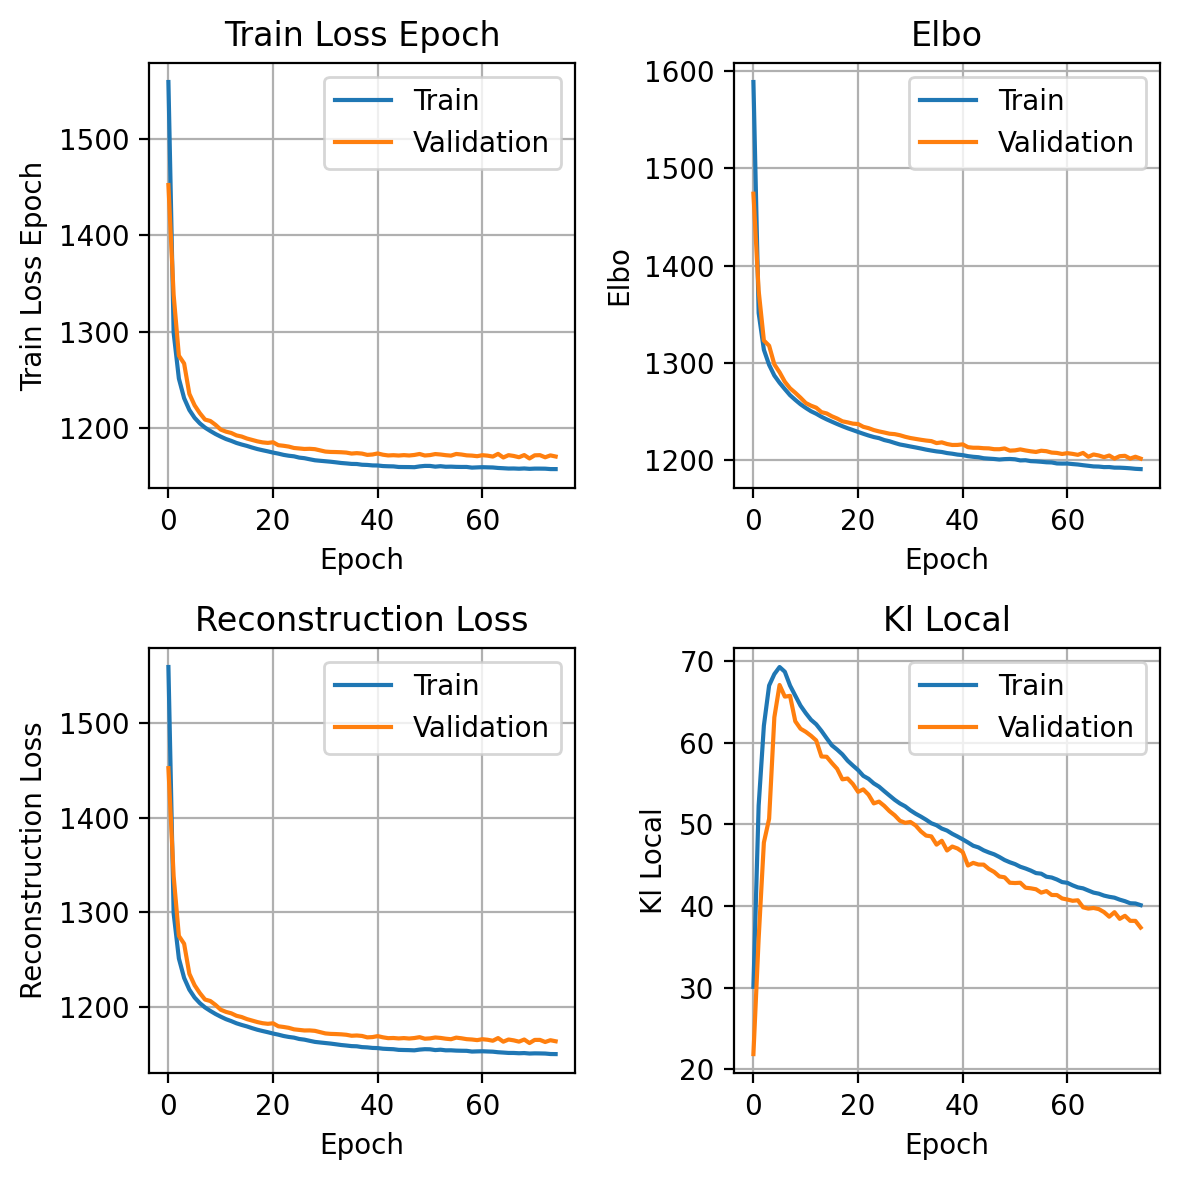

CPU times: user 1min 42s, sys: 8.28 s, total: 1min 50s
Wall time: 1min 58s


In [11]:
%%time
batch_key = "batch_key"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['highly_variable']].copy()
bdata.X = bdata.layers['raw_counts'].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=5500,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=200,
    accelerator='gpu',
    early_stopping_patience=5,
    early_stopping=True,
    batch_size=500,
    plan_kwargs={"lr": 1e-3},
)

# clear cache once finished
torch.cuda.empty_cache()     

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Embedding

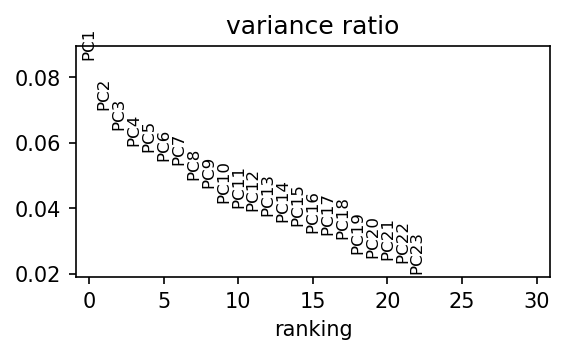

CPU times: user 1.09 s, sys: 68.5 ms, total: 1.16 s
Wall time: 2.36 s


In [12]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

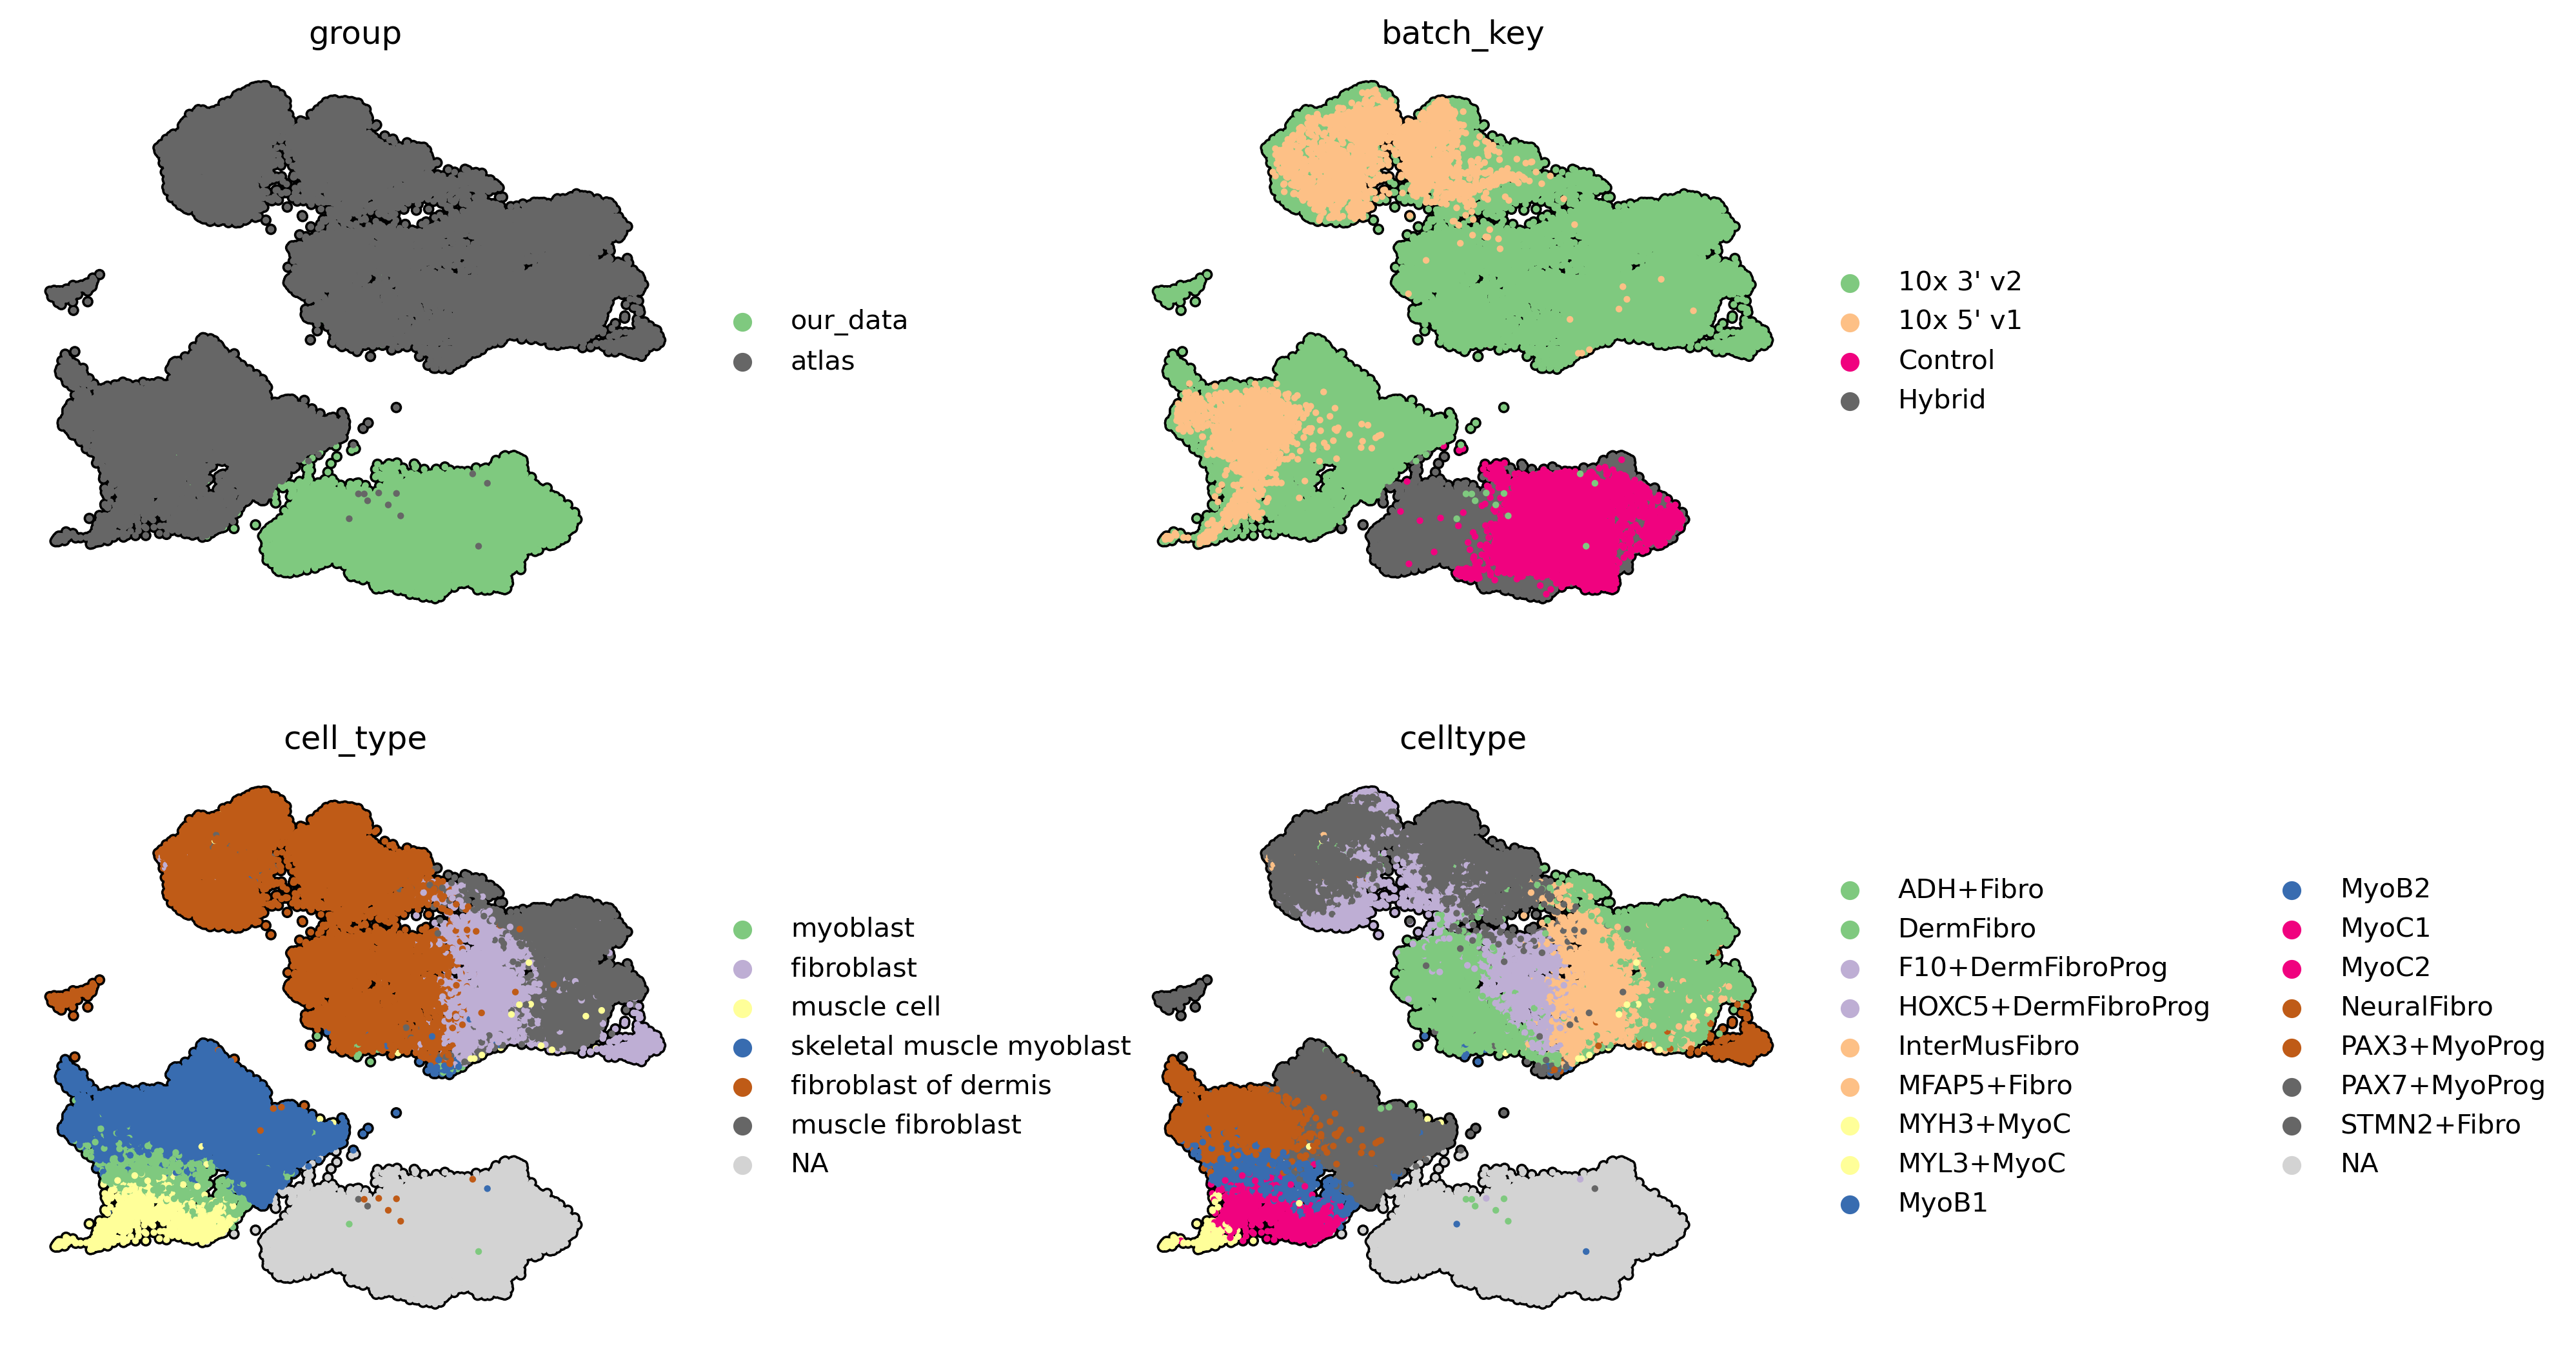

CPU times: user 6.22 s, sys: 117 ms, total: 6.33 s
Wall time: 6.39 s


In [22]:
%%time
n_neighbors = 100
n_pcs = 10
min_dist = 0.5
resolution = 0.75 

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

rsc.tl.umap(embed, min_dist=min_dist)


plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed,
    color=['group', 'batch_key', 'cell_type', 'celltype'],
    # color=['group', 'dataset', 'assay', 'tissue'],
    palette='Accent',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [28]:
embed

AnnData object with n_obs × n_vars = 52570 × 24
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_id',

In [29]:
cols = ['region', 'adj_stage', 'adj_sample', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id',
        'development_stage_ontology_term_id', 'donor_id', 'is_primary_data', 'suspension_type', 'tissue_type', 
        'cell_type', 'assay', 'disease', 'sex', 'tissue', 'development_stage']

embed.obs[cols].tail()

,region,adj_stage,adj_sample,celltype,assay_ontology_term_id,cell_type_ontology_term_id,development_stage_ontology_term_id,donor_id,is_primary_data,suspension_type,tissue_type,cell_type,assay,disease,sex,tissue,development_stage
TTTGCGCCACGGTGTC-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,PAX3+MyoProg,EFO:0011025,CL:0000515,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,skeletal muscle myoblast,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGCGCTCGGCGCAT-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,HOXC5+DermFibroProg,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTAGTGGGTTG-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTCAAGTCTAC-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16
TTTGGTTGTCGTGGCT-WSSS_THYst9384958,Proximal,Pcw5.6,Pcw5.6_Proximal_LowerLimb,STMN2+Fibro,EFO:0011025,CL:0002551,HsapDv:0000023,WSSS_THYst9384958,True,cell,tissue,fibroblast of dermis,10x 5' v1,normal,male,hindlimb,Carnegie stage 16


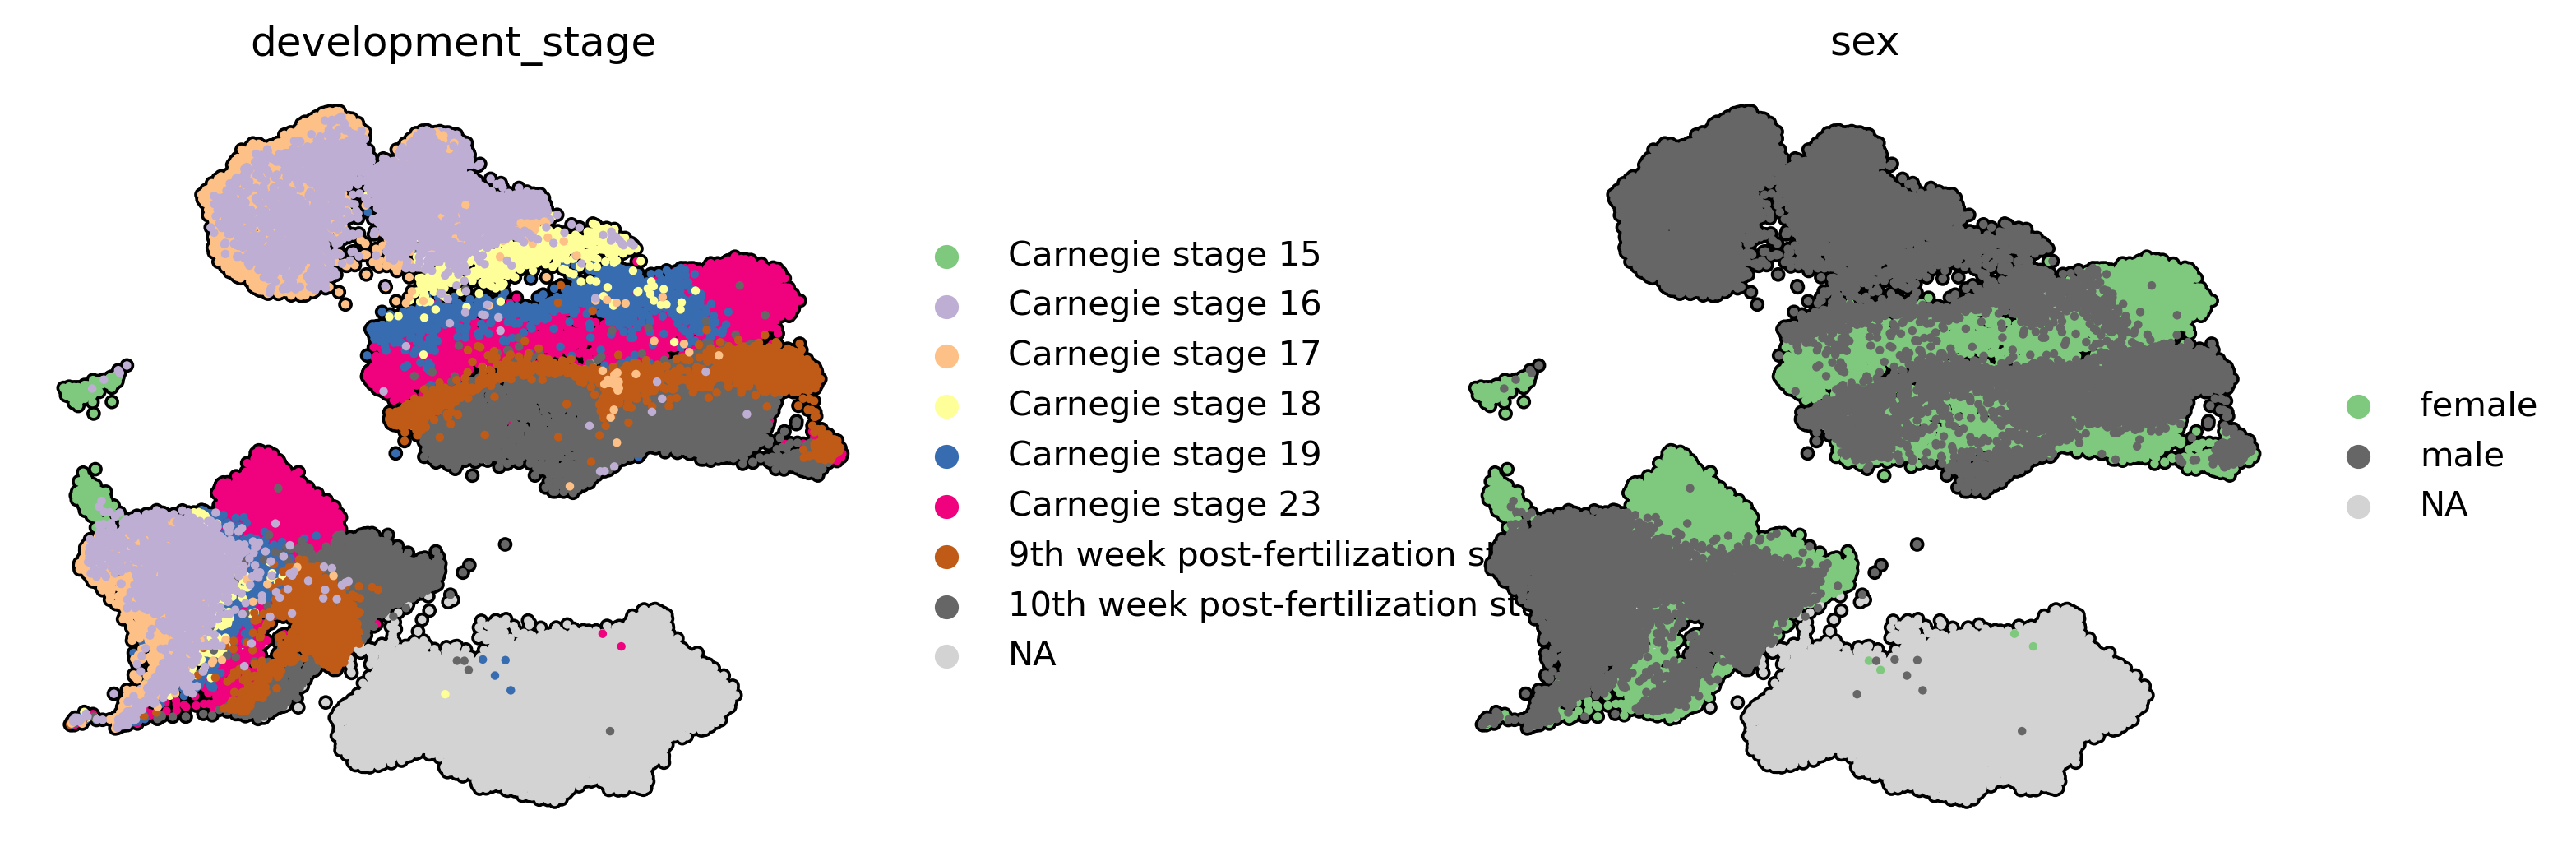

In [36]:
sc.pl.umap(
    embed,
    color=['development_stage', 'sex'],
    palette='Accent',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [37]:
embed.obs['donor_id'].value_counts()

donor_id
5478STDY7935101      5073
5478STDY7935102      3705
FCAImmP7536759       3445
FCAImmP7536758       3215
WSSS_THYst8796437    2020
5478STDY7980349      1938
5478STDY7980348      1798
5386STDY7557335      1675
5478STDY7652318      1464
5478STDY7717491      1273
5478STDY7717492      1204
5386STDY7557336      1132
5386STDY7557337      1112
WSSS_THYst9384954    1072
WSSS_THYst9384955    1019
WSSS_THYst9384957     922
WSSS_THYst8796438     911
WSSS_THYst8796441     878
WSSS_THYst9384958     588
5386STDY7537944       522
WSSS_THYst8796442     441
WSSS_THYst8796439     382
WSSS_THYst8796440     349
WSSS_THYst9384956     281
WSSS_THYst9384953     201
Name: count, dtype: int64

# Cluster

2025-09-22 12:27:21 | [INFO] init
... storing 'cluster' as categorical



cluster
A2     11336
A3      7588
A11     5815
A5      4899
A6      3913
A10     3828
A7      3666
A9      3662
A8      2374
A4      2301
A1      2263
A12      534
A13      391



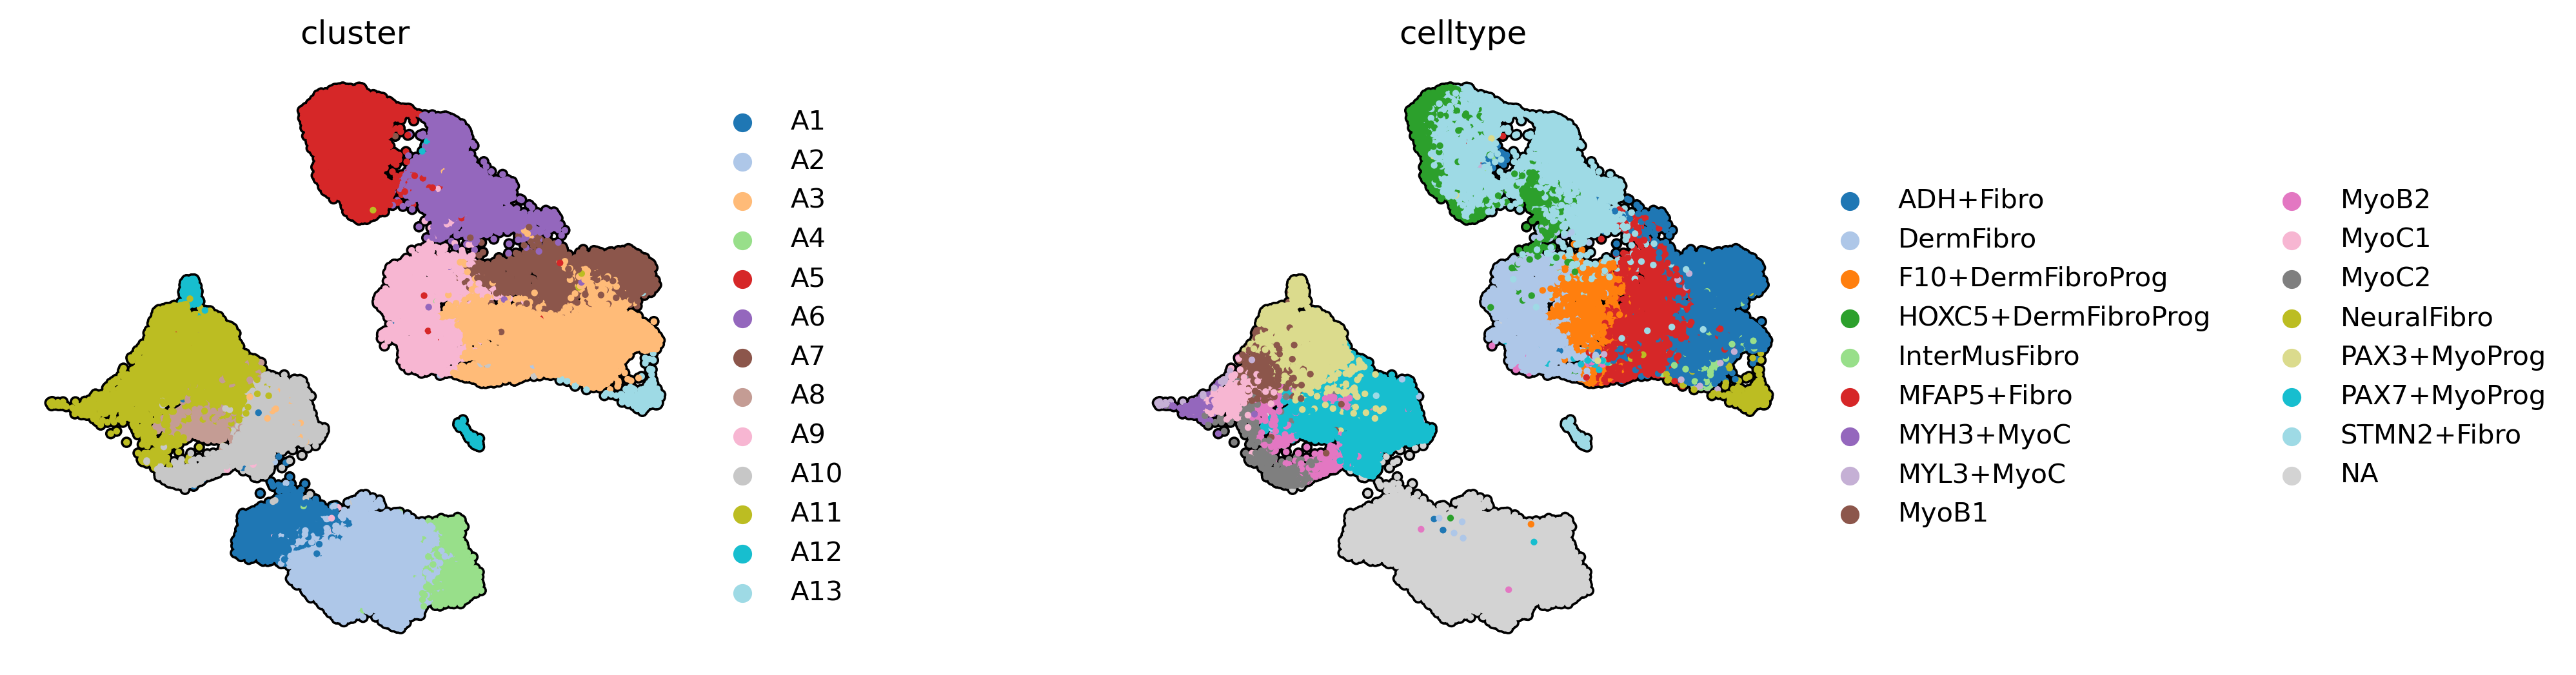

In [14]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

rsc.tl.leiden(embed, resolution=resolution)

embed.obs['cluster'] = embed.obs['leiden'].apply(lambda x: f"A{int(x) + 1}")
embed.obs['cluster'] = embed.obs['cluster'].astype('str')

print()
print(embed.obs['cluster'].value_counts().to_string())
print()

sc.pl.umap(
    embed,
    color=['cluster', 'celltype'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Add Coords

... storing 'phase' as categorical
... storing 'observation_joinid' as categorical
... storing 'batch_key' as categorical


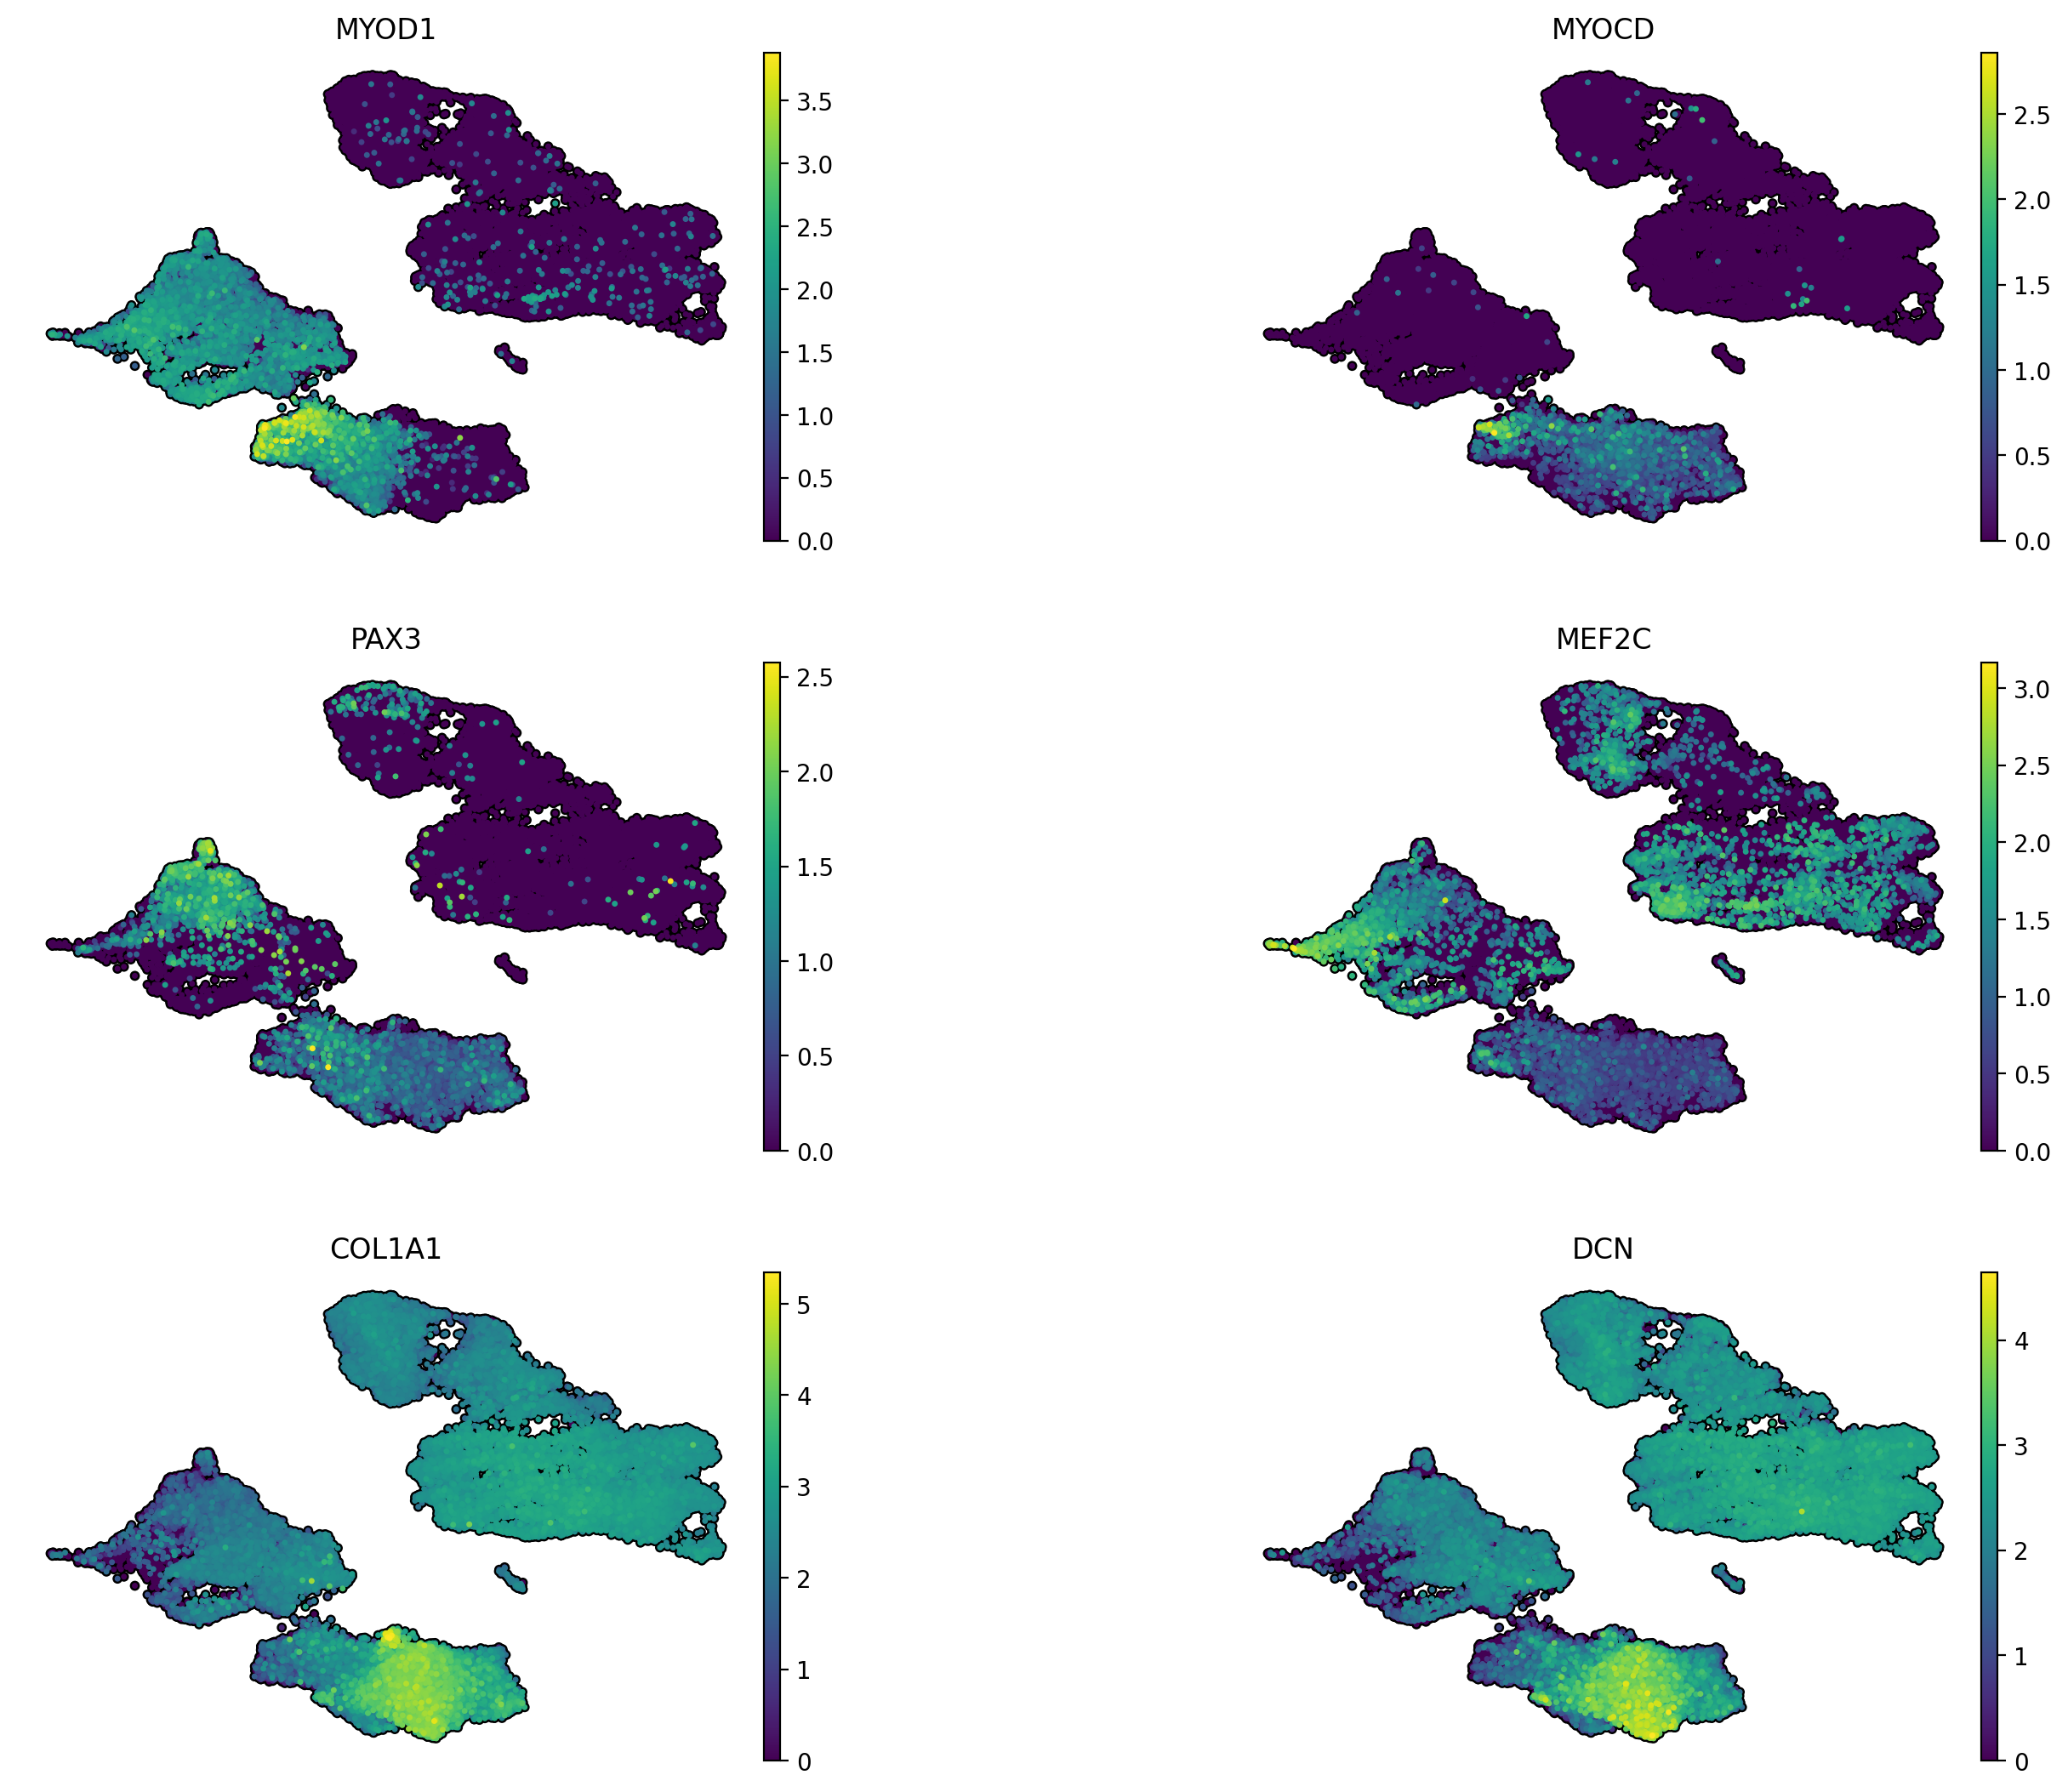

In [15]:
adata.obsm['X_umap'] = embed.obsm['X_umap'].copy()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4

sc.pl.umap(
    adata,
    color=['MYOD1', 'MYOCD', 'PAX3', 'MEF2C', 'COL1A1', 'DCN'],
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Add SCVI expression

In [16]:
df = model.get_normalized_expression()
adata.uns['scvi'] = df
adata

AnnData object with n_obs × n_vars = 52570 × 27475
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'group', 'percent_mito', 'n_counts', 'n_genes', 'doublet_scores', 'bh_pval', 'region', 'adj_stage', 'adj_sample', 'leiden_R', 'celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'disease_ontology_term_i

In [17]:
[x for x in adata.uns['scvi'] if x.startswith('MYO')]

['MYO15A',
 'MYO15B',
 'MYO16',
 'MYO18B',
 'MYO3A',
 'MYO3B',
 'MYOD1',
 'MYOG',
 'MYOM1',
 'MYOM2',
 'MYOM3',
 'MYORG',
 'MYOT',
 'MYOZ1',
 'MYOZ2',
 'MYOZ3']

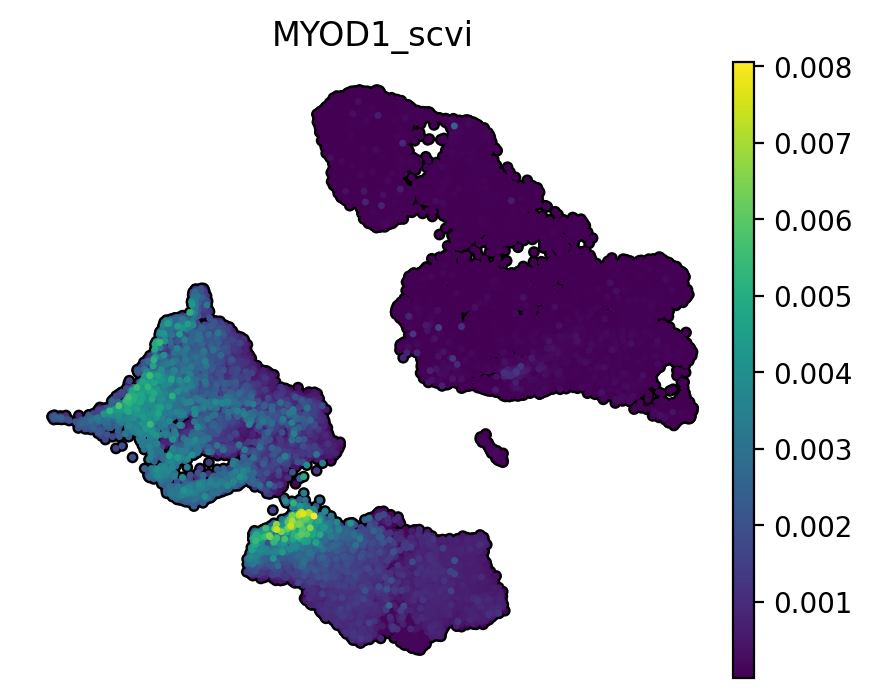

In [18]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4

color = 'MYOD1'
adata.obs[f"{color}_scvi"] = adata.uns['scvi'][color]

sc.pl.umap(
    adata,
    color=f"{color}_scvi",
    palette='tab20',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# Write out

In [19]:
# %%time
# outpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/reference_atlas/hybrid_muscle_atlas.h5ad"
# adata.write(outpath)
# adata 